# 02c - Data analysis

**Aim:** describe the training and benchmarking datasets independently through their sequence lengths, SP composition, taxonomy, and cleavage-site motifs.

We use the representative sequences and metadata prepared in 02b, keeping their saved split and fold assignments.

**Materials**
- `02c-DataAnalysis-2026.pdf` (slides 6, 7 and 12)
- `Plotting in Seaborn.pdf` (Import libraries, Setting the theme, Distribution plots and Categorical plots)


## 0. Load the prepared datasets

We load both classes' metadata and the positive sequences needed to study SPs. The `split` column identifies training and benchmarking proteins.


### 0.1 Imports and paths

We use pandas DataFrames with Seaborn and Matplotlib, following the plotting examples. Paths are relative to `notebooks/`.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
input_dir = Path("../data/prepared")


### 0.2 Load the metadata

We retain the original columns, including `cleavage_pos` for positives and `has_tm_in_90` for negatives. We read `cv_fold` as a nullable integer because benchmarking proteins have no fold assignment.


In [2]:
positive_metadata = pd.read_csv(
    input_dir / "positive_dataset.tsv", sep="\t", dtype={"cv_fold": "Int64"}
)
negative_metadata = pd.read_csv(
    input_dir / "negative_dataset.tsv", sep="\t", dtype={"cv_fold": "Int64"}
)


### 0.3 Load the positive sequences

We reuse the FASTA reader from 02b to keep full sequences in a dictionary keyed by `accession`, matching the positive metadata.


In [3]:
def read_fasta(fasta_path):
    sequences = {}
    with open(fasta_path, encoding="utf-8") as fasta_in:
        for line in fasta_in:
            line = line.strip()
            if line.startswith(">"):
                accession = line[1:].split()[0]
                sequences[accession] = ""
            elif line:
                sequences[accession] += line
    return sequences


In [4]:
positive_sequences = read_fasta(input_dir / "positive_dataset.fasta")


## 1. Length distributions

We describe training and benchmarking separately (02c slides 6 and 12). We compare histograms, boxplots and violin plots (slide 7) before choosing the final figures. The code follows the Distribution plots and Categorical plots sections of `Plotting in Seaborn.pdf`.

We combine the two classes only for plotting, keeping their saved splits. All figures use linear axes with shared scales between panels. We first show the full protein-length range, then apply the visualization cutoff described below. We also retain the full SP-length histogram before applying a separate SP-length cutoff.


In [5]:
protein_lengths = pd.concat([
    positive_metadata[["length", "split"]].assign(protein_class="Positive"),
    negative_metadata[["length", "split"]].assign(protein_class="Negative"),
], ignore_index=True)

sp_lengths = positive_metadata[["cleavage_pos", "split"]]

split_order = ["training", "benchmarking"]
class_order = ["Positive", "Negative"]
class_palette = {"Positive": "C0", "Negative": "C1"}

protein_bin_width = 100
protein_bins = list(range(
    0, int(protein_lengths["length"].max()) + protein_bin_width,
    protein_bin_width
))
sp_bins = [
    position - 0.5
    for position in range(
        int(sp_lengths["cleavage_pos"].min()),
        int(sp_lengths["cleavage_pos"].max()) + 2
    )
]


### 1.1 Protein lengths


#### 1.1.1 Full-range histogram

Following the Seaborn Distribution plots example, we use `displot(kind="hist")`. We use common 100-residue intervals to compare the distributions. Each class is normalized separately within each split, so the larger negative set does not dominate the comparison. Unfilled contours keep overlapping distributions visible.


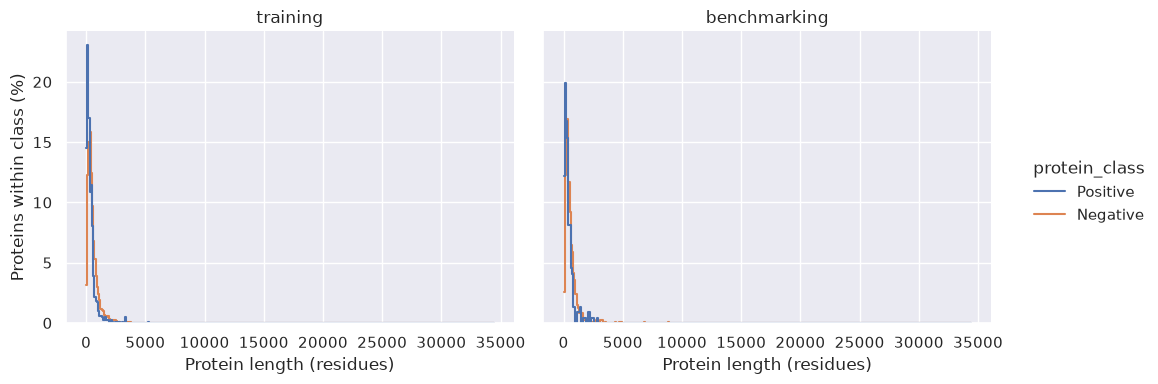

In [6]:
g = sns.displot(
    data=protein_lengths, x="length", hue="protein_class",
    hue_order=class_order, palette=class_palette,
    col="split", col_order=split_order,
    kind="hist", bins=protein_bins,
    stat="percent", common_norm=False,
    element="step", fill=False,
    height=4, aspect=1.3
)
g.set_axis_labels("Protein length (residues)", "Proteins within class (%)")
g.set_titles("{col_name}")
plt.show()


#### 1.1.2 Focus on the central length range

The longest proteins compress the main distribution in the full-range histogram. We keep that plot as a reference and exclude lengths above the training set's 99th percentile from the following protein-length plots, using both classes together to define one threshold. Applying the same threshold to both classes and splits keeps the comparison consistent without choosing a separate cutoff from benchmarking.

This is our visualization choice, not a filtering requirement in 02c slides 6, 7 and 12. The prepared datasets remain unchanged. We keep linear axes and the Seaborn `displot`/`catplot` approach from the plotting support. The table reports exclusions; the cutoff need not remove exactly 1% from each group. Histogram percentages now refer to retained proteins within each class and split.


In [7]:
protein_length_cutoff = protein_lengths.loc[
    protein_lengths["split"] == "training", "length"
].quantile(0.99)

protein_lengths_trimmed = protein_lengths[
    protein_lengths["length"] <= protein_length_cutoff
]
trimmed_protein_bins = list(range(
    0, int(protein_length_cutoff) + protein_bin_width, protein_bin_width
))

print("Protein-length cutoff (residues):", protein_length_cutoff)
excluded_counts = (
    protein_lengths.assign(excluded=protein_lengths["length"] > protein_length_cutoff)
    .groupby(["split", "protein_class"])["excluded"]
    .agg(total="size", excluded="sum")
)
excluded_counts


Protein-length cutoff (residues): 2558.4000000000015


total  excluded
split        protein_class                 
benchmarking Negative        1817        22
             Positive         221         2
training     Negative        7265        74
             Positive         881         8

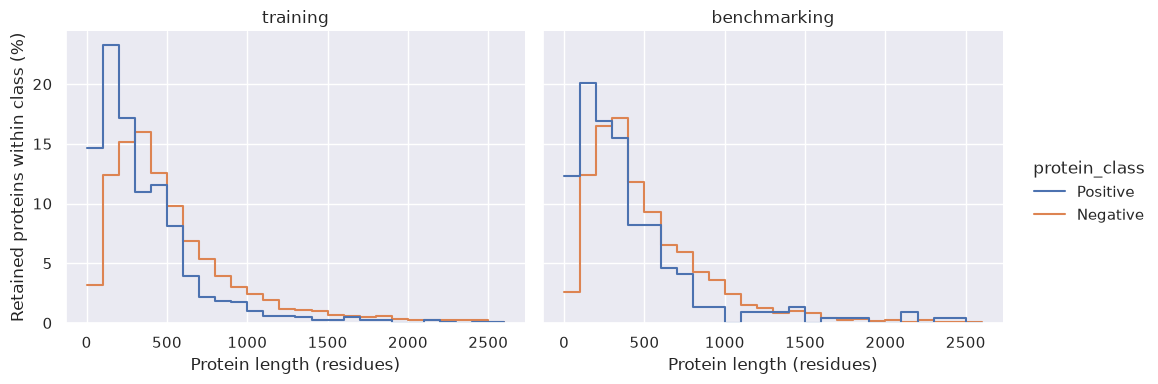

In [8]:
g = sns.displot(
    data=protein_lengths_trimmed, x="length", hue="protein_class",
    hue_order=class_order, palette=class_palette,
    col="split", col_order=split_order,
    kind="hist", bins=trimmed_protein_bins,
    stat="percent", common_norm=False,
    element="step", fill=False,
    height=4, aspect=1.3
)
g.set_axis_labels("Protein length (residues)", "Retained proteins within class (%)")
g.set_titles("{col_name}")
plt.show()


#### 1.1.3 Boxplot

Boxplots summarize medians and interquartile ranges (02c slide 7). We use `kind="box"` within the `catplot` family introduced in the Seaborn Categorical plots section. We use the same retained proteins as in section 1.1.2. Points beyond the whiskers within this subset remain visible.


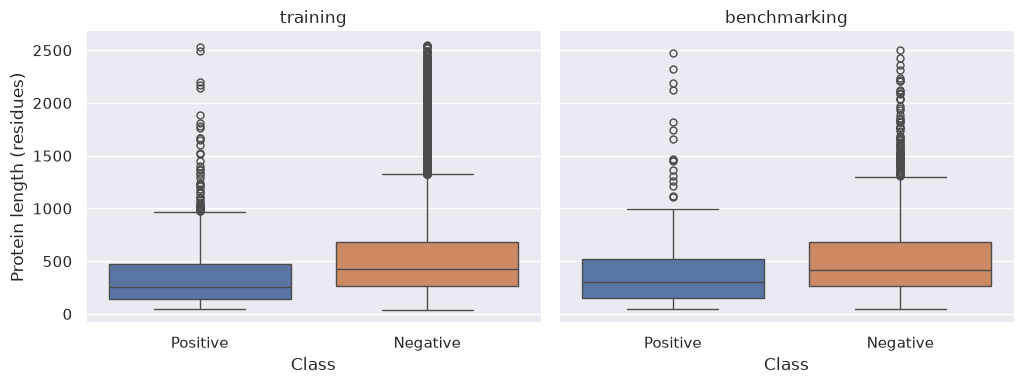

In [9]:
g = sns.catplot(
    data=protein_lengths_trimmed, x="protein_class", y="length",
    order=class_order, hue="protein_class",
    hue_order=class_order, palette=class_palette, legend=False,
    col="split", col_order=split_order,
    kind="box", height=4, aspect=1.3
)
g.set_axis_labels("Class", "Protein length (residues)")
g.set_titles("{col_name}")
plt.show()


#### 1.1.4 Violin plot

We use the same retained proteins as in section 1.1.2. Following the Seaborn `catplot(kind="violin")` example, we show a smoothed distribution with an inner box summary. We keep the default smoothing and set `cut=0` to stop the curves at the observed limits. Equal-area normalization makes width describe density rather than class abundance; the outline depends on smoothing.


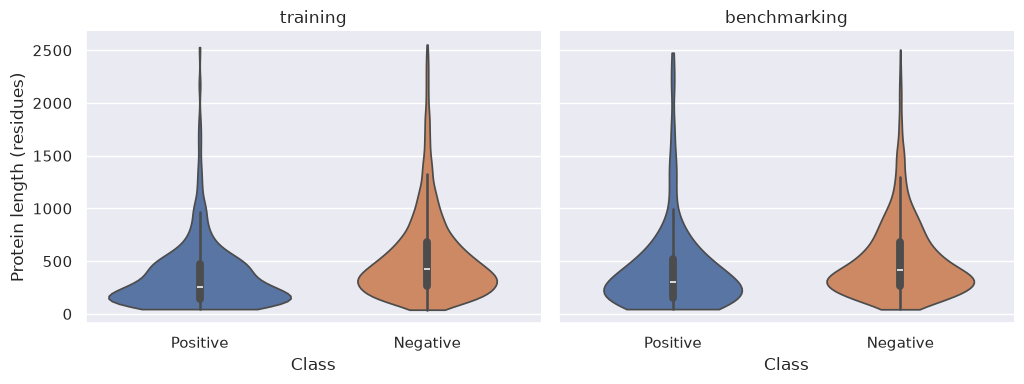

In [10]:
g = sns.catplot(
    data=protein_lengths_trimmed, x="protein_class", y="length",
    order=class_order, hue="protein_class",
    hue_order=class_order, palette=class_palette, legend=False,
    col="split", col_order=split_order,
    kind="violin", cut=0, inner="box",
    density_norm="area", common_norm=True,
    height=4, aspect=1.3
)
g.set_axis_labels("Class", "Protein length (residues)")
g.set_titles("{col_name}")
plt.show()


### 1.2 Signal-peptide lengths


#### 1.2.1 Full-range histogram

For positive proteins, `cleavage_pos` gives the SP length, as established in 02a. We use the same histogram method with one-residue intervals centred on integers and common edges across splits. Percentages are calculated independently within each split.


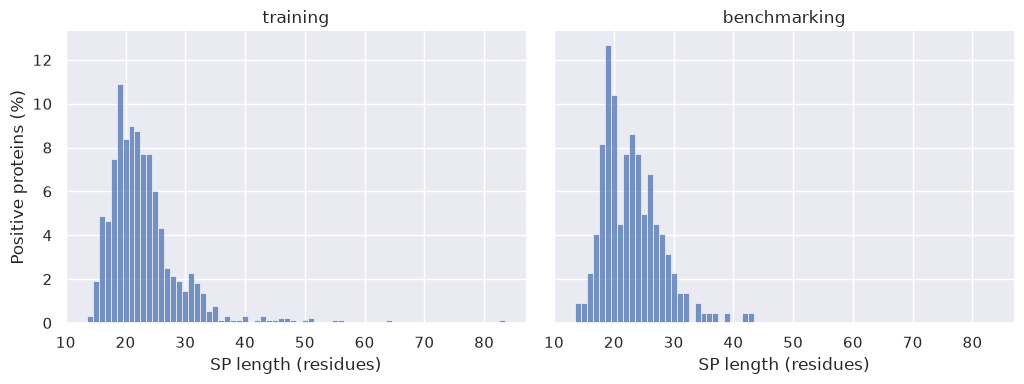

In [11]:
g = sns.displot(
    data=sp_lengths, x="cleavage_pos",
    col="split", col_order=split_order,
    kind="hist", bins=sp_bins,
    stat="percent", common_norm=False,
    color=class_palette["Positive"],
    height=4, aspect=1.3
)
g.set_axis_labels("SP length (residues)", "Positive proteins (%)")
g.set_titles("{col_name}")
plt.show()


#### 1.2.2 Focus on the central SP-length range

We keep the full-range histogram above and exclude SP lengths above the training 99th percentile from the following SP-length plots. This cutoff is calculated from positive training proteins and applied unchanged to benchmarking. It is separate from the full-protein cutoff in section 1.1.2.

As with the protein plots, this is our visualization choice rather than a requirement of 02c slides 6 and 12. We retain linear axes and the Seaborn plotting approach. The table reports exclusions, and histogram percentages refer to retained positives within each split. This trims the upper tail; a dense peak is not necessarily an outlier. The original metadata and sequences remain unchanged.


In [12]:
sp_length_cutoff = sp_lengths.loc[
    sp_lengths["split"] == "training", "cleavage_pos"
].quantile(0.99)

sp_lengths_trimmed = sp_lengths[
    sp_lengths["cleavage_pos"] <= sp_length_cutoff
]
trimmed_sp_bins = [
    position - 0.5
    for position in range(
        int(sp_lengths_trimmed["cleavage_pos"].min()),
        int(sp_length_cutoff) + 2
    )
]

print("SP-length cutoff (residues):", sp_length_cutoff)
sp_excluded_counts = (
    sp_lengths.assign(excluded=sp_lengths["cleavage_pos"] > sp_length_cutoff)
    .groupby("split")["excluded"]
    .agg(total="size", excluded="sum")
)
sp_excluded_counts


SP-length cutoff (residues): 47.0


,total,excluded
split,,
benchmarking,221,0
training,881,8


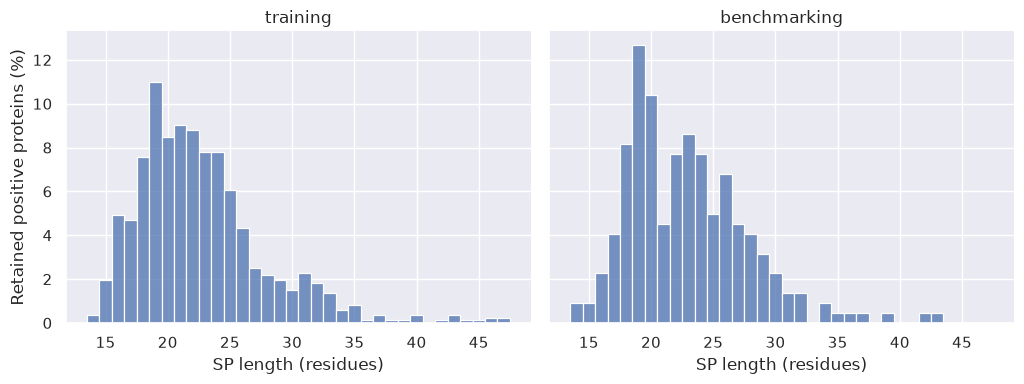

In [13]:
g = sns.displot(
    data=sp_lengths_trimmed, x="cleavage_pos",
    col="split", col_order=split_order,
    kind="hist", bins=trimmed_sp_bins,
    stat="percent", common_norm=False,
    color=class_palette["Positive"],
    height=4, aspect=1.3
)
g.set_axis_labels("SP length (residues)", "Retained positive proteins (%)")
g.set_titles("{col_name}")
plt.show()


#### 1.2.3 Boxplot

We summarize SP lengths with the same boxplot convention used for full proteins, keeping training and benchmarking in separate panels.

We use the SP-length subset retained in section 1.2.2.


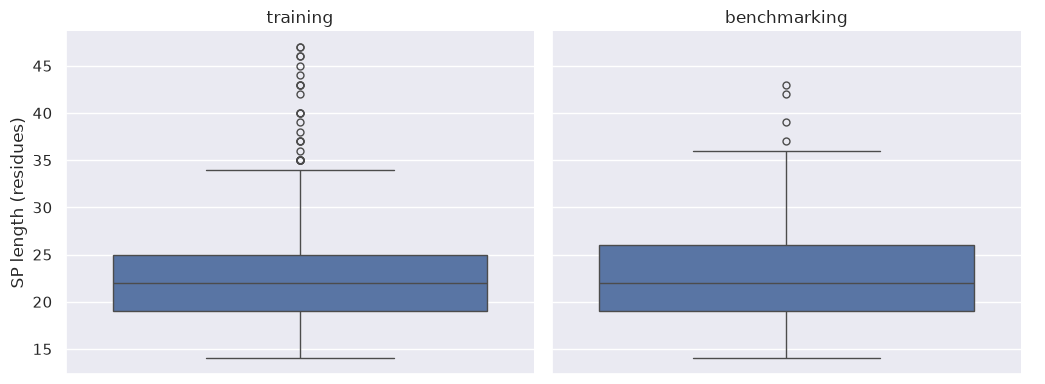

In [14]:
g = sns.catplot(
    data=sp_lengths_trimmed, y="cleavage_pos",
    col="split", col_order=split_order,
    kind="box", color=class_palette["Positive"],
    height=4, aspect=1.3
)
g.set_axis_labels("", "SP length (residues)")
g.set_titles("{col_name}")
plt.show()


#### 1.2.4 Violin plot

We use the same violin settings for SP lengths. The smooth outline approximates a distribution of integer lengths; its width does not represent the number of proteins in the split. We compare these views before choosing which figures to retain.

We use the SP-length subset retained in section 1.2.2.


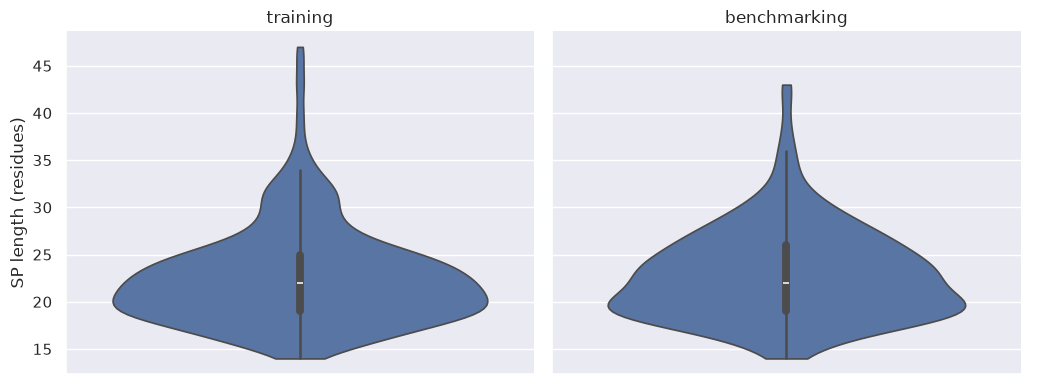

In [15]:
g = sns.catplot(
    data=sp_lengths_trimmed, y="cleavage_pos",
    col="split", col_order=split_order,
    kind="violin", color=class_palette["Positive"],
    cut=0, inner="box", density_norm="area", common_norm=True,
    height=4, aspect=1.3
)
g.set_axis_labels("", "SP length (residues)")
g.set_titles("{col_name}")
plt.show()


### 1.3 Observations

- **Protein lengths:** in both splits, retained positive proteins tend to be shorter than negatives. Their histograms concentrate more strongly at short lengths, and their boxplots show lower medians and narrower interquartile ranges. However, the distributions overlap substantially, so length alone does not clearly separate the classes.
- **SP lengths:** training and benchmarking show similar central distributions, with medians around 22 residues and most of the central half near 19–26 residues. Both have a right tail, although individual histogram peaks differ. This supports comparable SP-length distributions across the splits, rather than proving that they are balanced in every respect; class proportions and taxonomy are separate questions.
- **Effect of trimming:** these comparisons describe the retained subsets. The protein cutoff is approximately 2558 residues. The SP cutoff is 47 residues and excludes eight training proteins but no benchmarking proteins, so their upper tails are not identical. The full-range histograms preserve that context. These are descriptive observations, not a statistical test of equivalence.


## 2. Signal-peptide amino-acid composition

We compare SP composition with SwissProt separately for training and benchmarking, using grouped bars as requested in 02c slides 6 and 12. We follow the `catplot(kind="bar")` example in the Categorical plots section of `Plotting in Seaborn.pdf`.

We use all positive proteins: the P99 cutoffs in step 1 were only used to display length distributions. SwissProt provides a general protein background, not the composition of our negative class or an exclusively eukaryotic reference.


### 2.1 Extract the signal peptides

As established in 02a, `cleavage_pos` is the last residue of the SP, starting at position 1. The slice `sequence[:cleavage_pos]` therefore retains the complete SP and excludes the mature protein.


In [16]:
sp_sequences = {}
for row in positive_metadata.itertuples(index=False):
    sp_sequences[row.accession] = positive_sequences[row.accession][:row.cleavage_pos]


### 2.2 SwissProt reference

We retain the published percentages from [SwissProt release statistics, section 6.1](https://web.expasy.org/docs/relnotes/relstat.html), release **2026_03 (2 September 2026)**, consulted on **24 September 2026**. The values below are a fixed copy of that table, so later website updates do not change this comparison.

We normalize these rounded percentages over the 20 canonical amino acids to match the denominator used for SPs.


In [17]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
swissprot_percent = {
    "A": 8.25, "C": 1.38, "D": 5.46, "E": 6.71, "F": 3.86,
    "G": 7.07, "H": 2.27, "I": 5.90, "K": 5.79, "L": 9.64,
    "M": 2.41, "N": 4.06, "P": 4.75, "Q": 3.93, "R": 5.52,
    "S": 6.66, "T": 5.36, "V": 6.85, "W": 1.10, "Y": 2.92,
}
swissprot_total = sum(swissprot_percent.values())


### 2.3 Count residues and compare compositions

We pool SP residues within each split and calculate each amino acid's percentage among known canonical residues. Each residue contributes equally, so longer SPs contribute more residues; this is a residue composition rather than an average of per-protein percentages.

Unknown residues (`X`) are excluded from the denominator, while the other residues of the same protein are retained. The summary reports all non-canonical residues excluded from counting, together with the number of SPs and counted residues.


In [18]:
composition_rows = []
residue_summary = []

for split in split_order:
    accessions = positive_metadata.loc[
        positive_metadata["split"] == split, "accession"
    ]
    residues = "".join(sp_sequences[accession] for accession in accessions)
    counts = {aa: residues.count(aa) for aa in amino_acids}
    known_residues = sum(counts.values())

    residue_summary.append({
        "split": split,
        "SPs": len(accessions),
        "Canonical residues": known_residues,
        "Excluded non-canonical residues": len(residues) - known_residues,
    })

    for aa in amino_acids:
        composition_rows.append({
            "split": split, "amino_acid": aa, "source": "SP",
            "percentage": 100 * counts[aa] / known_residues,
        })
        composition_rows.append({
            "split": split, "amino_acid": aa, "source": "SwissProt",
            "percentage": 100 * swissprot_percent[aa] / swissprot_total,
        })

aa_composition = pd.DataFrame(composition_rows)
pd.DataFrame(residue_summary)


,split,SPs,Canonical residues,Excluded non-canonical residues
0,training,881,20225,11
1,benchmarking,221,5065,0


We use the same amino-acid order, colors and percentage scale in both panels. Each bar represents an aggregated composition, so we omit error bars. Differences from SwissProt describe enrichment or depletion relative to this general background; they do not directly measure differences between our positive and negative classes.


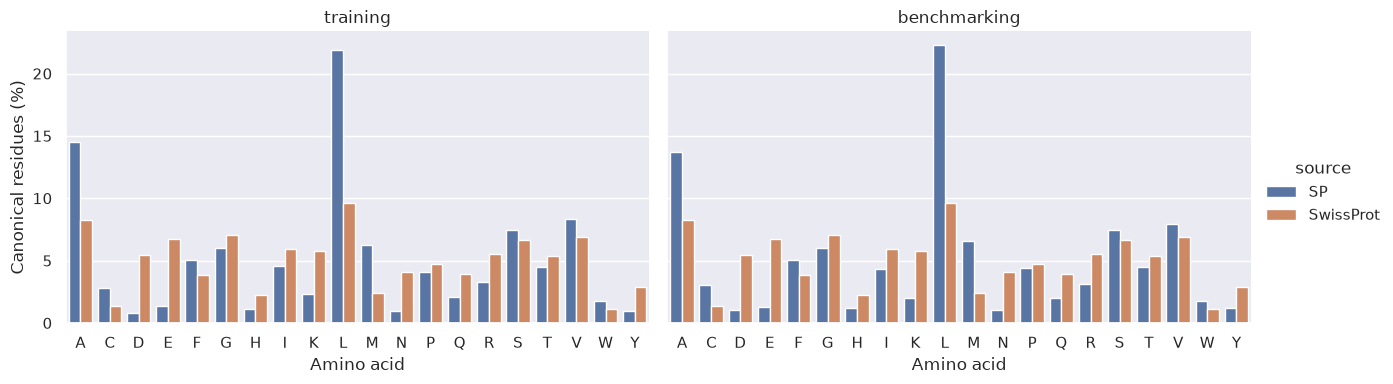

In [19]:
g = sns.catplot(
    data=aa_composition, x="amino_acid", y="percentage",
    order=amino_acids, hue="source", hue_order=["SP", "SwissProt"],
    palette={"SP": "C0", "SwissProt": "C1"},
    col="split", col_order=split_order,
    kind="bar", errorbar=None,
    height=4, aspect=1.6
)
g.set_axis_labels("Amino acid", "Canonical residues (%)")
g.set_titles("{col_name}")
plt.show()


### 2.4 Observations

In both training and benchmarking, signal peptides show higher proportions of alanine (A) and especially leucine (L) than the SwissProt background. Aspartate (D), histidine (H), asparagine (N) and glutamate (E) are less represented. Tyrosine (Y) also has a slightly lower proportion than in SwissProt.

The same broad pattern appears in both splits. These observations describe the SP regions of positive proteins relative to a general SwissProt background, rather than a comparison of complete positive and negative proteins. We have not tested the statistical significance of these differences.
